In [1]:
from tensorflow.keras.layers import Rescaling
from tensorflow.keras import layers, models
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from glob import glob
import cv2
import os
import shutil
import numpy as np
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
image_fake = '/content/drive/My Drive/fake-images/data/image-fake/'
image_real = '/content/drive/My Drive/fake-images/data/image-real/'


image_fake_paths = glob(os.path.join(image_fake, '*.*'))  # قراءة جميع الملفات
image_real_paths = glob(os.path.join(image_real, '*.*'))  # قراءة جميع الملفات

In [4]:
!ls '/content/drive/My Drive/fake-images/data'

image-fake  image_labels.csv  image-real


# **Image Size Distribution**


In [ ]:

def get_image_sizes(directory):
    widths, heights = [], []
    for filename in os.listdir(directory):
        filepath = os.path.join(directory, filename)
        try:
            with Image.open(filepath) as img:

                widths.append(img.width)
                heights.append(img.height)
        except Exception as e:
            print(f"Error processing {filename}: {e}")
    print(heights)
    print(widths)
    return widths, heights

#Get dimensions for fake and real images
fake_widths, fake_heights = get_image_sizes(image_fake)
real_widths, real_heights = get_image_sizes(image_real)


[218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218, 218]
[178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178

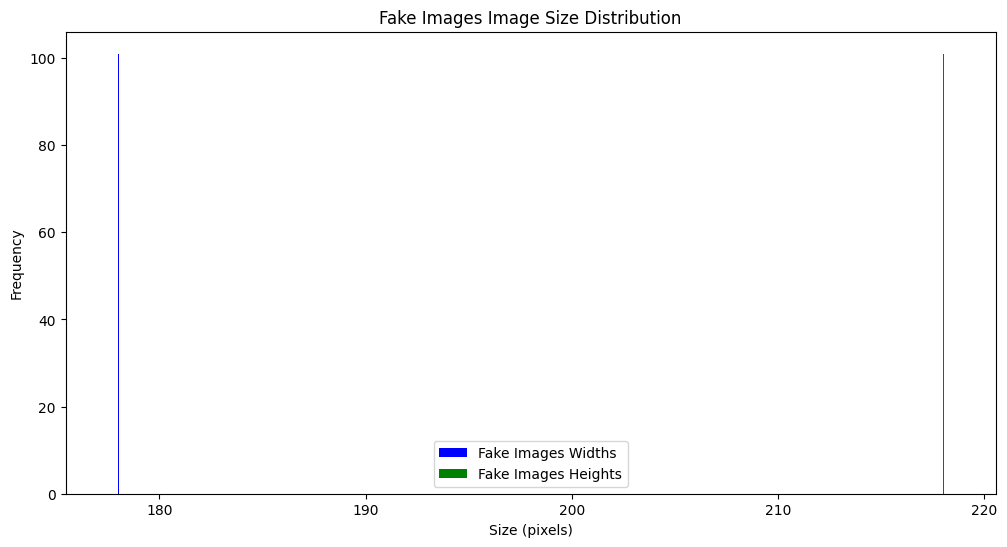

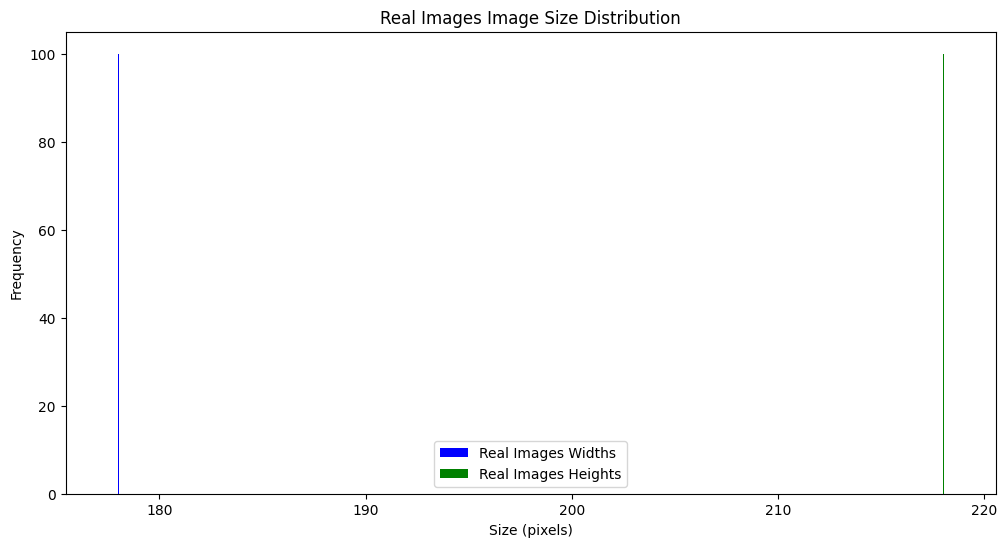

In [ ]:
# Plotting the distributions
def plot_size_distribution(widths, heights, label):
    plt.figure(figsize=(12, 6))
    plt.hist(widths, bins=30, alpha=1.0, label=f'{label} Widths', color='blue')
    plt.hist(heights, bins=30, alpha=1.0, label=f'{label} Heights', color='green')
    plt.xlabel('Size (pixels)')
    plt.ylabel('Frequency')
    plt.title(f'{label} Image Size Distribution')
    plt.legend()
    plt.show()

# Plot for fake images
plot_size_distribution(fake_widths, fake_heights, "Fake Images")

# Plot for real images
plot_size_distribution(real_widths, real_heights, "Real Images")

# **Color Channel Statistics: Calculate mean, variance, and distribution of RGB values**

In [ ]:
def calculate_color_statistics(directory):
    r_values, g_values, b_values = [], [], []

    if not os.path.exists(directory):
        print(f"Directory not found: {directory}")
        return None

    for filename in os.listdir(directory):
        filepath = os.path.join(directory, filename)
        try:
            with Image.open(filepath) as img:
                # Ensure image is in RGB mode
                img = img.convert('RGB')
                # Convert image to NumPy array
                np_img = np.array(img)
                # Extract R, G, B channels
                r_values.extend(np_img[:, :, 0].flatten())
                g_values.extend(np_img[:, :, 1].flatten())
                b_values.extend(np_img[:, :, 2].flatten())
        except Exception as e:
            print(f"Error processing {filename}: {e}")

    # Calculate statistics
    r_mean, r_var = np.mean(r_values), np.var(r_values)
    g_mean, g_var = np.mean(g_values), np.var(g_values)
    b_mean, b_var = np.mean(b_values), np.var(b_values)

    stats = {
        'Red': {'mean': r_mean, 'variance': r_var},
        'Green': {'mean': g_mean, 'variance': g_var},
        'Blue': {'mean': b_mean, 'variance': b_var},
    }
    return stats, r_values, g_values, b_values

In [ ]:
def plot_color_distributions(r_values, g_values, b_values, label):
    plt.figure(figsize=(12, 6))
    plt.hist(r_values, bins=30, alpha=0.5, color='red', label='Red')
    plt.hist(g_values, bins=30, alpha=0.5, color='green', label='Green')
    plt.hist(b_values, bins=30, alpha=0.5, color='blue', label='Blue')
    plt.title(f"RGB Value Distribution for {label}")
    plt.xlabel('Pixel Value (0-255)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

Fake Image Statistics: {'Red': {'mean': 138.00378010432732, 'variance': 4360.240989496275}, 'Green': {'mean': 113.76682994812212, 'variance': 3489.908928100358}, 'Blue': {'mean': 100.44655113640422, 'variance': 3493.0396776213697}}


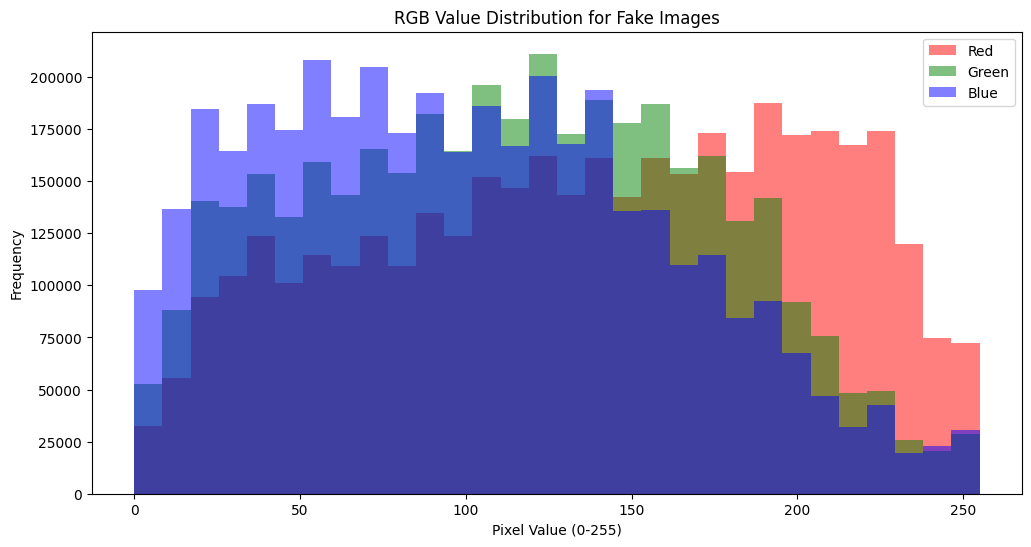

Real Image Statistics: {'Red': {'mean': 130.79533269766003, 'variance': 6273.478758908998}, 'Green': {'mean': 109.15525023193486, 'variance': 5212.736297581959}, 'Blue': {'mean': 97.57648360993711, 'variance': 5254.68837301795}}


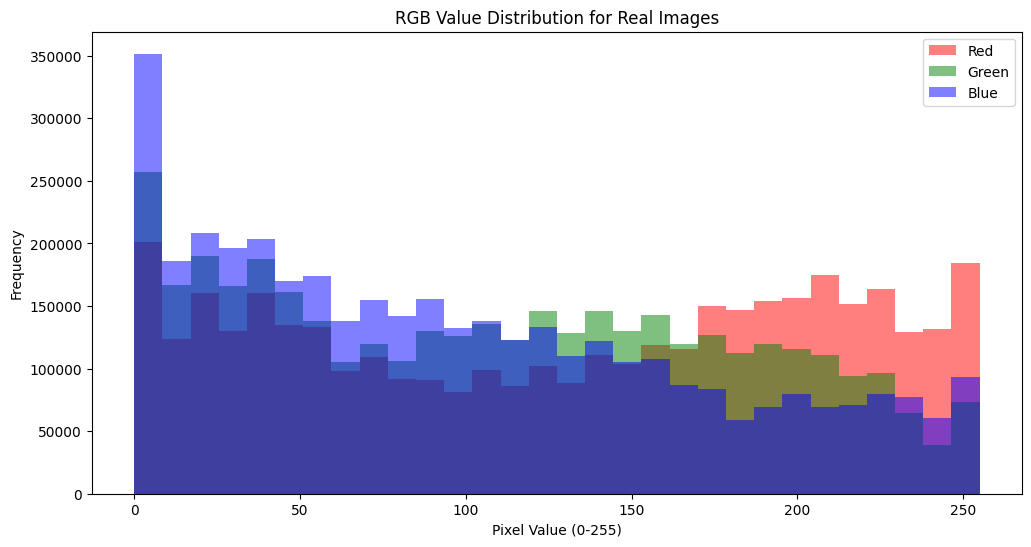

In [ ]:
# Calculate statistics and plot for fake images
fake_stats, fake_r, fake_g, fake_b = calculate_color_statistics(image_fake)
if fake_stats:
    print("Fake Image Statistics:", fake_stats)
    plot_color_distributions(fake_r, fake_g, fake_b, "Fake Images")

# Calculate statistics and plot for real images
real_stats, real_r, real_g, real_b = calculate_color_statistics(image_real)
if real_stats:
    print("Real Image Statistics:", real_stats)
    plot_color_distributions(real_r, real_g, real_b, "Real Images")

# **Image Sharpness/Blur Detection: Measure sharpness to identify poor-quality images**
To measure the sharpness or blur of an image, we will use techniques that analyze edges or gradients. A popular method is Laplacian Variance, which computes the variance of the Laplacian of an image. A lower variance indicates a blurrier image.

In [ ]:
def measure_blur(filepath):
    try:
        # Open image in grayscale
        image = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError("Image not found or unreadable")
        # Apply Laplacian to calculate the second derivative
        laplacian = cv2.Laplacian(image, cv2.CV_64F)
        # Compute variance of the Laplacian
        blur = laplacian.var()
        return blur
    except Exception as e:
        print(f"Error processing {filepath}: {e}")
        return None

In [ ]:
def analyze_blur(directory):
    blur_scores = []
    if not os.path.exists(directory):
        print(f"Directory not found: {directory}")
        return cv2.blur_scores
    for filename in os.listdir(directory):
        filepath = os.path.join(directory, filename)
        score = measure_blur(filepath)
        if score is not None:
            blur_scores.append(score)
    return blur_scores

In [ ]:
def plot_blur_distribution(blur_scores, label):
    if not blur_scores:
        print(f"No sharpness/Blur data to plot for {label}.")
        return
    plt.figure(figsize=(12, 6))
    plt.hist(blur_scores, bins=30, alpha=0.7, color='blue')
    plt.title(f"Sharpness/Blur Distribution for {label}")
    plt.xlabel("Sharpness/Blur Score (Laplacian Variance)")
    plt.ylabel("Frequency")
    plt.show()

Fake Images - Mean Sharpness: 494.01


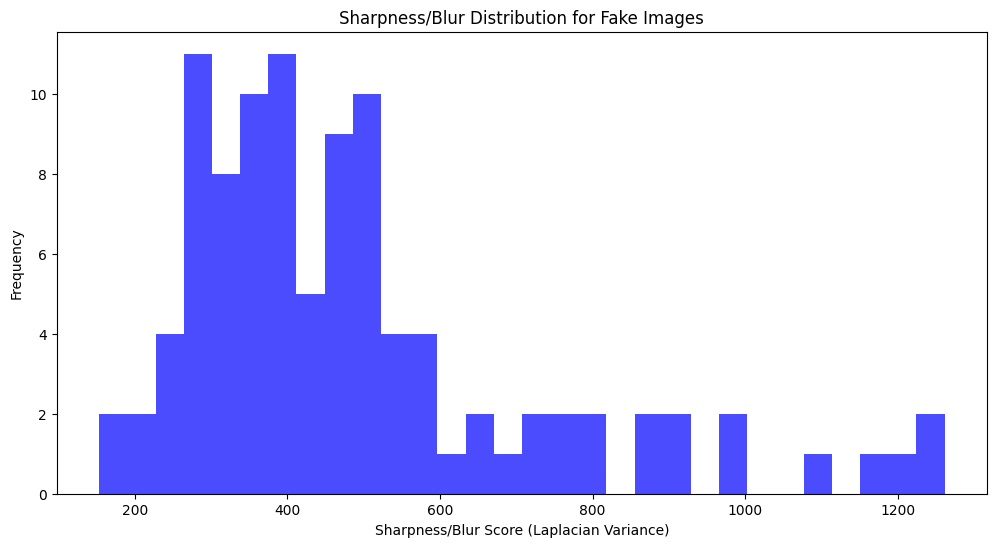

Real Images - Mean Sharpness: 881.04


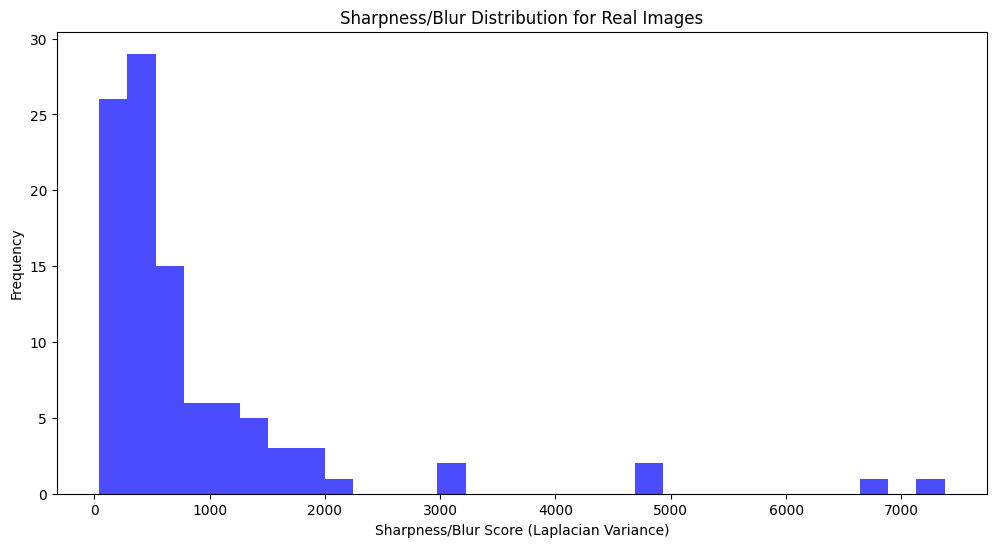

In [ ]:
# Analyze sharpness for fake images
fake_blur = analyze_blur(image_fake)
if fake_blur:
    print(f"Fake Images - Mean Sharpness: {np.mean(fake_blur):.2f}")
    plot_blur_distribution(fake_blur, "Fake Images")

# Analyze sharpness for real images
real_blur = analyze_blur(image_real)
if real_blur:
    print(f"Real Images - Mean Sharpness: {np.mean(real_blur):.2f}")
    plot_blur_distribution(real_blur, "Real Images")

A histogram of sharpness scores provides insights into the quality distribution of images.

# **Pixel Intensity Histogram Analysis**

In [ ]:
def calculate_intensity_histogram(filepath, mode='grayscale'):
    try:
        # Load image
        image = cv2.imread(filepath)
        if image is None:
            raise ValueError("Image not found or unreadable")

        # Grayscale mode
        if mode == 'grayscale':
            gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            histogram = cv2.calcHist([gray_image], [0], None, [256], [0, 256])
            return histogram.flatten()

        # RGB mode
        elif mode == 'rgb':
            channels = ['Blue', 'Green', 'Red']
            histograms = {}
            for i, color in enumerate(channels):
                hist = cv2.calcHist([image], [i], None, [256], [0, 256])
                histograms[color] = hist.flatten()
            return histograms
        else:
            raise ValueError("Invalid mode. Choose 'grayscale' or 'rgb'")
    except Exception as e:
        print(f"Error processing {filepath}: {e}")
        return None

In [ ]:
def analyze_intensity_histograms(directory, mode='grayscale'):
    histograms = []
    if not os.path.exists(directory):
        print(f"Directory not found: {directory}")
        return histograms
    for filename in os.listdir(directory):
        filepath = os.path.join(directory, filename)
        hist = calculate_intensity_histogram(filepath, mode=mode)
        if hist is not None:
            histograms.append(hist)
    return histograms

In [ ]:
def plot_intensity_histogram(histograms, label, mode='grayscale'):
    if not histograms:
        print(f"No histograms to plot for {label}.")
        return

    plt.figure(figsize=(12, 6))

    if mode == 'grayscale':
        # Average histogram for all images
        avg_histogram = np.mean(histograms, axis=0)
        plt.plot(avg_histogram, color='black', label='Grayscale')
    elif mode == 'rgb':
        # Separate histograms for RGB channels
        colors = ['Blue', 'Green', 'Red']
        avg_histograms = {color: np.mean([h[color] for h in histograms], axis=0) for color in colors}
        for color, avg_hist in avg_histograms.items():
            plt.plot(avg_hist, label=f'{color} Channel')

    plt.title(f"Pixel Intensity Histogram ({label})")
    plt.xlabel("Pixel Intensity (0-255)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid()
    plt.show()

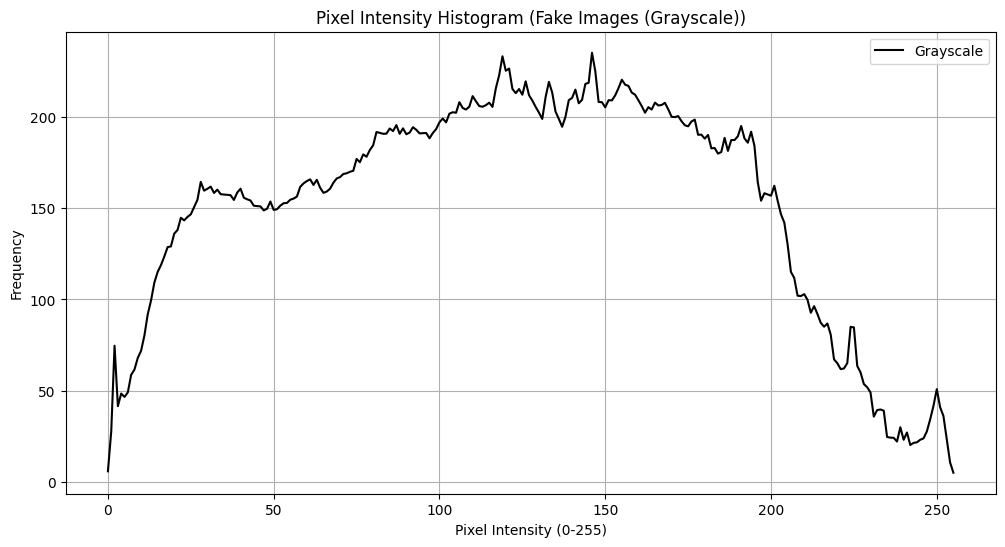

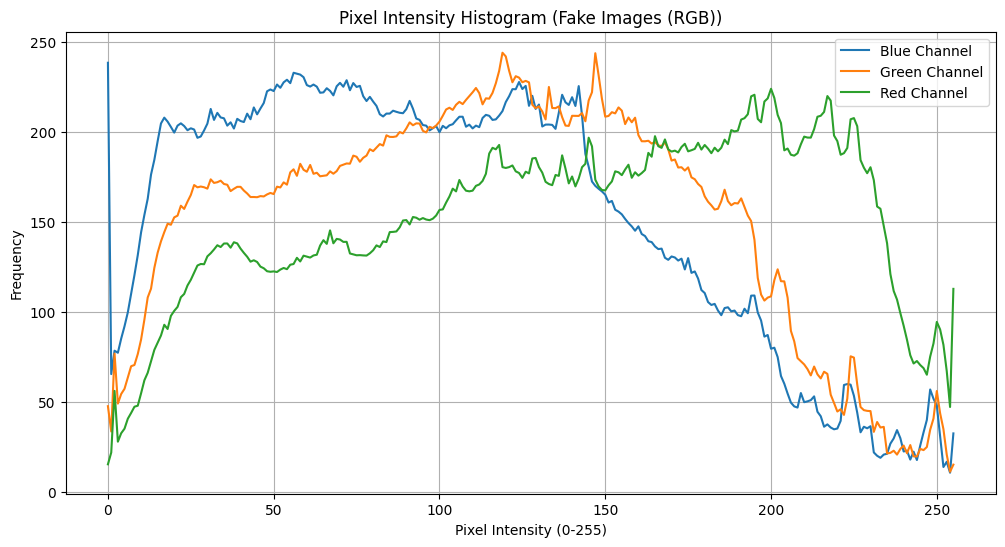

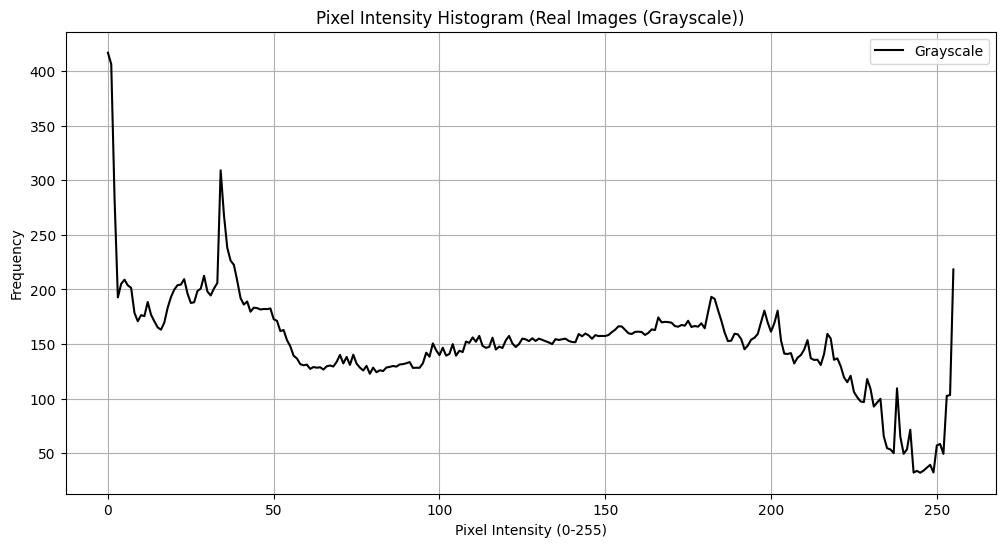

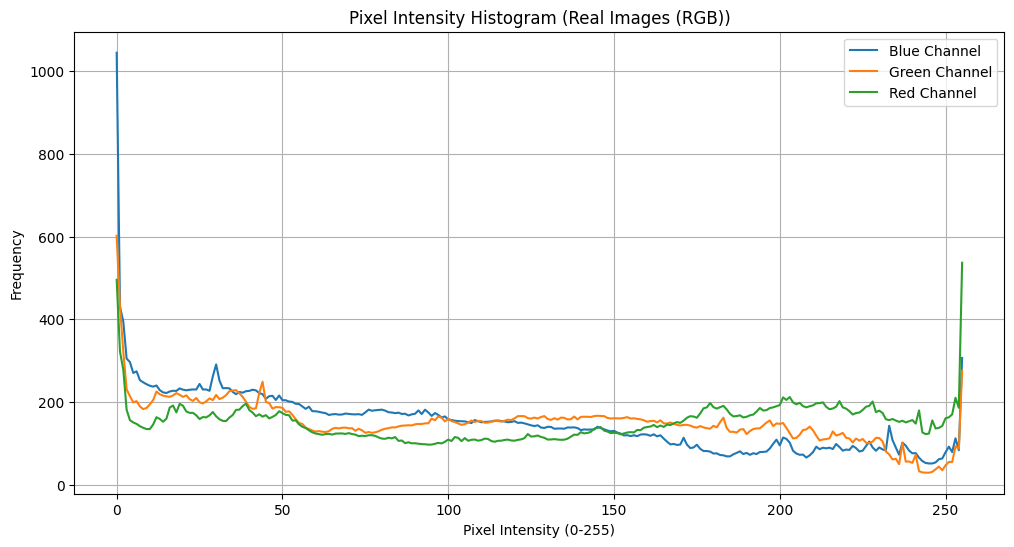

In [ ]:
# Analyze grayscale histograms for fake images
fake_grayscale_histograms = analyze_intensity_histograms(image_fake, mode='grayscale')
plot_intensity_histogram(fake_grayscale_histograms, "Fake Images (Grayscale)", mode='grayscale')

# Analyze RGB histograms for fake images
fake_rgb_histograms = analyze_intensity_histograms(image_fake, mode='rgb')
plot_intensity_histogram(fake_rgb_histograms, "Fake Images (RGB)", mode='rgb')

# Analyze grayscale histograms for real images
real_grayscale_histograms = analyze_intensity_histograms(image_real, mode='grayscale')
plot_intensity_histogram(real_grayscale_histograms, "Real Images (Grayscale)", mode='grayscale')

# Analyze RGB histograms for real images
real_rgb_histograms = analyze_intensity_histograms(image_real, mode='rgb')
plot_intensity_histogram(real_rgb_histograms, "Real Images (RGB)", mode='rgb')


# **Prepare to model (Preprocessing)**

# For the size of the images, all images have the same width and height as we explained above.

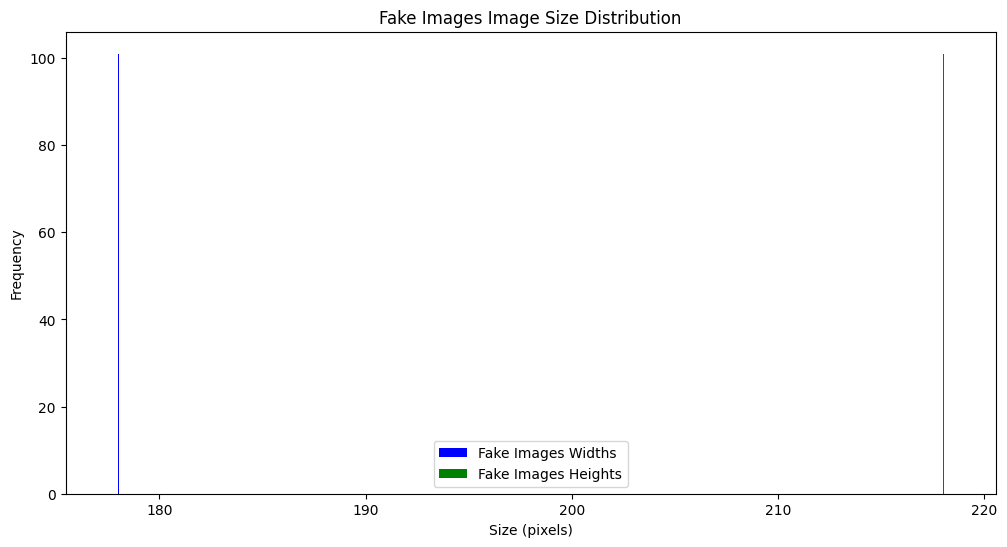

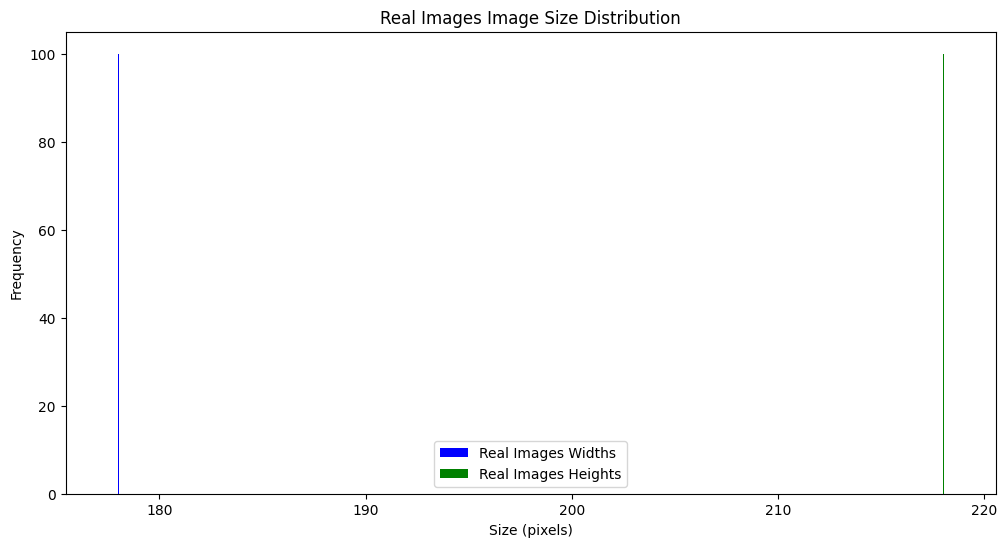

In [ ]:
# Plot for fake images
plot_size_distribution(fake_widths, fake_heights, "Fake Images")

# Plot for real images
plot_size_distribution(real_widths, real_heights, "Real Images")

'/content/drive/My Drive/fake-images/data/image_labels.csv/'

In [5]:
import os
import pandas as pd

# Paths to the folders containing images
image_fake_folder = "/content/drive/My Drive/fake-images/data/image-fake/"
image_real_folder = "/content/drive/My Drive/fake-images/data/image-real/"

# Output CSV file
output_csv = '/content/drive/My Drive/fake-images/image_label'

# Create a list to store file paths and labels
data = []

# Process fake images
for filename in os.listdir(image_fake_folder):
    filepath = os.path.join(image_fake_folder, filename)
    if os.path.isfile(filepath):
        data.append({"path": filepath, "label": 0})  # Label '0' for fake

# Process real images
for filename in os.listdir(image_real_folder):
    filepath = os.path.join(image_real_folder, filename)
    if os.path.isfile(filepath):
        data.append({"path": filepath, "label": 1})  # Label '1' for real

# Create a DataFrame and save it as a CSV file
df = pd.DataFrame(data)
df.to_csv(output_csv, index=False)
print(f"Data saved to {output_csv}")


Data saved to /content/drive/My Drive/fake-images/image_label


In [6]:
df.head()

,path,label
0,/content/drive/My Drive/fake-images/data/image...,0
1,/content/drive/My Drive/fake-images/data/image...,0
2,/content/drive/My Drive/fake-images/data/image...,0
3,/content/drive/My Drive/fake-images/data/image...,0
4,/content/drive/My Drive/fake-images/data/image...,0


# **Normalization: Scale pixel values to a specific range (0 , 1)**

In [6]:
def normalize_image(image_path):
    try:
        with Image.open(image_path) as img:
            img = img.convert('RGB')  # Ensure the image is in RGB format
            img_array = np.array(img).astype('float32')  # Convert to NumPy array
            img_normalized = img_array / 255.0  # Normalize to range [0, 1]
            return img_normalized
    except Exception as e:
        print(f"Error loading image {image_path}: {e}")
        return None

In [7]:
import pandas as pd

def normalize_images_with_labels(csv_file):
    data = pd.read_csv(csv_file)
    normalized_images = []
    labels = []
    for _, row in data.iterrows():
        filepath, label = row['path'], row['label']
        normalized_image = normalize_image(filepath)
        if normalized_image is not None:
            normalized_images.append(normalized_image)
            labels.append(label)
    return np.array(normalized_images), np.array(labels)


csv_file = '/content/drive/My Drive/fake-images/image_label'
X, y = normalize_images_with_labels(csv_file)
print("Normalized Images Shape:", X.shape)
print("Labels Shape:", y.shape)

Normalized Images Shape: (201, 218, 178, 3)
Labels Shape: (201,)


In [9]:
X

array([[[[0.9647059 , 0.972549  , 0.96862745],
         [0.9647059 , 0.972549  , 0.96862745],
         [0.9647059 , 0.972549  , 0.96862745],
         ...,
         [0.9490196 , 0.9529412 , 0.9607843 ],
         [0.95686275, 0.9607843 , 0.96862745],
         [0.95686275, 0.9607843 , 0.96862745]],

        [[0.9647059 , 0.972549  , 0.96862745],
         [0.9647059 , 0.972549  , 0.96862745],
         [0.9647059 , 0.972549  , 0.96862745],
         ...,
         [0.9490196 , 0.9529412 , 0.9607843 ],
         [0.9490196 , 0.9529412 , 0.9607843 ],
         [0.9490196 , 0.9529412 , 0.9607843 ]],

        [[0.9647059 , 0.972549  , 0.96862745],
         [0.9647059 , 0.972549  , 0.96862745],
         [0.9647059 , 0.972549  , 0.96862745],
         ...,
         [0.9490196 , 0.9529412 , 0.9607843 ],
         [0.9411765 , 0.94509804, 0.9529412 ],
         [0.9411765 , 0.94509804, 0.9529412 ]],

        ...,

        [[0.9843137 , 0.9843137 , 0.9764706 ],
         [0.9843137 , 0.9843137 , 0.9764706 ]

# Grayscale Conversion: Reduce color channels
# **Gray=0.2989⋅R+0.5870⋅G+0.1140⋅B**

In [8]:
import os
import numpy as np
from PIL import Image
import pandas as pd

def normalize_and_grayscale(image_path):
    """
    Normalizes an image to [0, 1] and converts it to grayscale.
    """
    try:
        with Image.open(image_path) as img:
            img = img.convert('RGB')
            # Convert to NumPy array
            img_array = np.array(img).astype('float32')

            # Normalize pixel values to [0, 1]
            img_normalized = img_array / 255.0

            # Convert to grayscale using the luminance formula
            grayscale = 0.2989 * img_normalized[:, :, 0] + \
                        0.5870 * img_normalized[:, :, 1] + \
                        0.1140 * img_normalized[:, :, 2]
            return grayscale
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None

In [9]:
def normalize_and_grayscale_with_labels(csv_file):
    """
    Reads image paths and labels from a CSV, normalizes, converts to grayscale, and returns X, y.
    """
    data = pd.read_csv(csv_file)
    processed_images = []
    labels = []
    for _, row in data.iterrows():
        filepath, label = row['path'], row['label']
        processed_image = normalize_and_grayscale(filepath)
        if processed_image is not None:
            processed_images.append(processed_image)
            labels.append(label)

    # Convert to NumPy arrays
    # X Shape: (num_samples, height, width)
    X = np.array(processed_images)
    # Y Shape: (num_samples,)
    y = np.array(labels)
    return X, y

# Example usage
csv_file = '/content/drive/My Drive/fake-images/image_label'
X, y = normalize_and_grayscale_with_labels(csv_file)

print("Shape of X (images):", X.shape)
print("Shape of y (labels):", y.shape)


Shape of X (images): (201, 218, 178)
Shape of y (labels): (201,)


# **Model**

In [13]:
from sklearn.model_selection import train_test_split
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
print(y_test)
print(y_train)

[0 0 0 1 1 1 0 1 1 0 0 1 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 1 1 1
 1 1 0 0]
[1 0 0 1 1 0 0 1 0 1 1 0 1 1 0 1 0 1 0 1 0 0 0 0 1 0 1 0 1 0 1 1 0 1 1 0 1
 0 1 0 0 0 1 1 0 1 0 1 0 0 1 1 0 0 1 1 0 0 1 0 0 1 1 1 1 0 0 1 1 1 0 1 1 0
 1 0 0 1 0 0 1 1 1 0 0 1 1 0 0 1 0 0 1 0 1 0 1 0 1 1 1 1 0 0 0 0 1 0 0 1 1
 0 0 0 0 1 1 0 0 1 1 1 1 0 0 1 0 1 1 0 0 0 0 0 1 1 1 0 1 1 0 0 1 1 1 1 0 1
 0 0 1 1 0 1 0 1 0 0 1 1]


***CNN Model***

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def create_cnn(input_shape):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')  # Output layer for binary classification
    ])

    # Compile the model
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


In [16]:
X_train = np.expand_dims(X_train, axis=-1)  # Shape becomes (num_samples, height, width, 1)
X_test = np.expand_dims(X_test, axis=-1)    # Shape becomes (num_samples, height, width, 1)


In [17]:
# CNN Training
cnn_input_shape = X_train.shape[1:]  # Shape: (height, width, channels)
cnn_model = create_cnn(cnn_input_shape)
history = cnn_model.fit(X_train, y_train, epochs=7, batch_size=32, validation_split=0.2)
print(history)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/7
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.5479 - loss: 2.8973 - val_accuracy: 0.4688 - val_loss: 0.9713
Epoch 2/7
4/4 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.5500 - loss: 0.8279 - val_accuracy: 0.5312 - val_loss: 0.6327
Epoch 3/7
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.6573 - loss: 0.5799 - val_accuracy: 0.9688 - val_loss: 0.5178
Epoch 4/7
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.8313 - loss: 0.4800 - val_accuracy: 1.0000 - val_loss: 0.3448
Epoch 5/7
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.9750 - loss: 0.2958 - val_accuracy: 0.9062 - val_loss: 0.2860
Epoch 6/7
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.9708 - loss: 0.1728 - val_accuracy: 0.9688 - val_loss: 0.1242
Epoch 7/7
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.9969 - loss: 0.0831 - val_accuracy: 0.9688 - val_loss: 0.0806


In [18]:
# Evaluation
cnn_loss, cnn_acc = cnn_model.evaluate(X_test, y_test)
print(f"CNN Accuracy: {cnn_acc}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - accuracy: 0.9304 - loss: 0.1393
CNN Accuracy: 0.9268292784690857


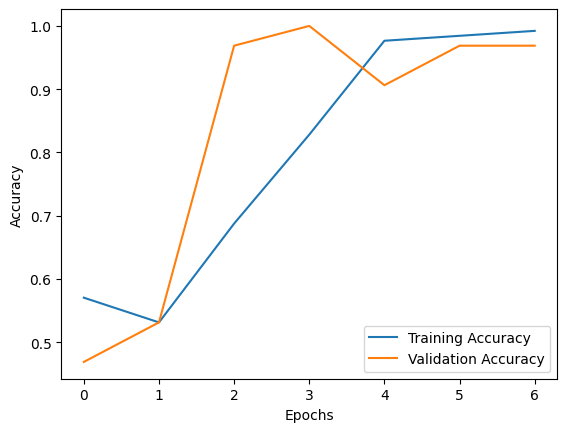

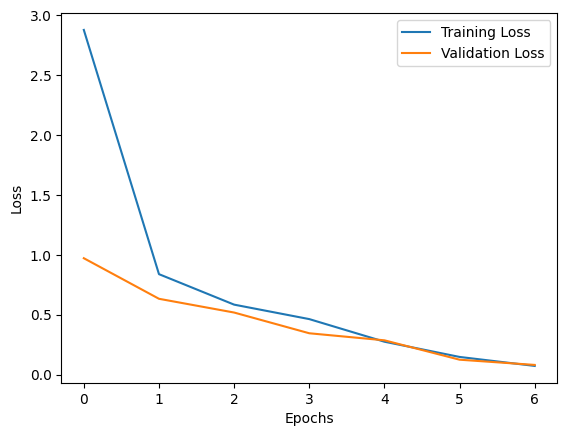

In [19]:
import matplotlib.pyplot as plt

# رسم دقة التدريب والتحقق
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# رسم الخسارة
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

ANN Model

In [24]:
def create_ann(input_dim):
    model = Sequential([
        # Dense(128, activation='relu', input_dim=input_dim),  # Fully connected layer
        # Dropout(0.3),  # Dropout for regularization
        # Dense(64, activation='relu'),  # Another dense layer
        # Dense(1, activation='sigmoid')  # Output layer for binary classification
        Dense(128, activation='relu', name='Dense_128'),
        Dropout(0.3, name='Dropout_1'),
        Dense(64, activation='relu', name='Dense_64'),
        Dropout(0.2, name='Dropout_2'),
        Dense(1, activation='sigmoid', name='OutputLayer')  # Binary classification
    ])

    # Compile the model
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [25]:
# ANN Training
# Flatten data for ANN
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

In [26]:
ann_input_dim = X_train_flat.shape[1]  # Number of features
ann_model = create_ann(ann_input_dim)
Ann= ann_model.fit(X_train_flat, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step - accuracy: 0.5573 - loss: 2.4859 - val_accuracy: 0.5312 - val_loss: 2.5885
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5708 - loss: 4.7762 - val_accuracy: 0.8750 - val_loss: 0.3789
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6990 - loss: 2.6335 - val_accuracy: 0.9375 - val_loss: 0.1953
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.7740 - loss: 1.2467 - val_accuracy: 0.9375 - val_loss: 0.1310
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7115 - loss: 1.4960 - val_accuracy: 0.9688 - val_loss: 0.1693
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.7740 - loss: 1.3017 - val_accuracy: 0.9688 - val_loss: 0.0885
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8292 - loss: 0.7197 - val_accuracy: 0.9375 - val_loss: 0.2137
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.8479 - loss: 0.5161 - val_accuracy: 0.9375 - val_loss: 0.178

In [27]:
ann_loss, ann_acc = ann_model.evaluate(X_test_flat, y_test)
print(f"ANN Accuracy: {ann_acc}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8504 - loss: 0.2297 
ANN Accuracy: 0.8536585569381714


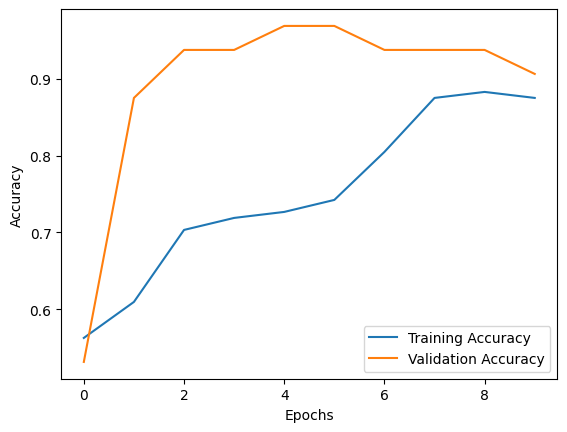

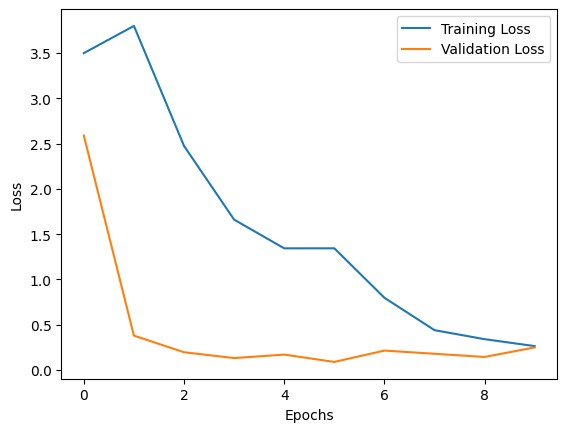

In [28]:
import matplotlib.pyplot as plt

# رسم دقة التدريب والتحقق
plt.plot(Ann.history['accuracy'], label='Training Accuracy')
plt.plot(Ann.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# رسم الخسارة
plt.plot(Ann.history['loss'], label='Training Loss')
plt.plot(Ann.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


# **pipeline**

In [29]:
pip install scikeras

In [32]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Input, Resizing, Rescaling, Lambda
import tensorflow as tf

def create_ann(input_shape=(178,218, 3), target_size=(178, 218)):
    model = Sequential([
        # Define the input shape here
        Input(shape=input_shape, name='InputLayer'),

        # Preprocessing layers directly in the model
        Resizing(target_size[1], target_size[0], name='ResizingLayer'),  # Resize images
        Rescaling(1.0 / 255, name='RescalingLayer'),  # Normalize pixel values to [0, 1]
        Lambda(lambda x: tf.image.rgb_to_grayscale(x), name='GrayscaleLayer'),  # Convert to Grayscale

        # Flattening Layer
        Flatten(name='FlattenLayer'),

        # Fully Connected Layers
        Dense(128, activation='relu', name='Dense_128'),
        Dropout(0.3, name='Dropout_1'),
        Dense(64, activation='relu', name='Dense_64'),
        Dropout(0.2, name='Dropout_2'),
        Dense(1, activation='sigmoid', name='OutputLayer')  # Binary classification
    ])

    # Compile the model
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


# Load and Split Data
csv_file = '/content/drive/My Drive/fake-images/image_label'
data = pd.read_csv(csv_file)
X_paths = data['path'].values
y_labels = data['label'].values

# Train-Test Split
X_train_paths, X_test_paths, y_train, y_test = train_test_split(X_paths, y_labels, test_size=0.2, random_state=42)

# Define a Data Generator for Image Loading
def image_loader(file_paths, target_size=(178, 218)):
    """
    Load images dynamically during training from file paths.
    """
    images = []
    for file_path in file_paths:
        try:
            img = tf.keras.preprocessing.image.load_img(file_path, target_size=target_size)
            img_array = tf.keras.preprocessing.image.img_to_array(img)
            images.append(img_array)
        except Exception as e:
            print(f"Error loading image {file_path}: {e}")
            continue
    return np.array(images)

# Custom Preprocessor Transformer for Image Loading
class ImageLoader:
    def __init__(self, target_size=(178, 218)):
        self.target_size = target_size

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return image_loader(X, target_size=self.target_size)

# Wrap the ANN Model with Scikeras
ann_classifier = KerasClassifier(
    model=create_ann,
    model__input_shape=(178, 218, 3),  # Define input shape
    model__target_size=(178, 218),     # Resize target shape
    epochs=10,
    batch_size=32,
    verbose=1,
    validation_split=0.2
)

# Define the Pipeline
pipeline = Pipeline([
    ('image_loader', ImageLoader(target_size=(178, 218))),  # Load and preprocess images
    ('ann', ann_classifier)  # Train ANN model
])

# Train the Pipeline
pipeline.fit(X_train_paths, y_train)

# Evaluate the Pipeline
score = pipeline.score(X_test_paths, y_test)
print(f"Test Accuracy: {score:.2f}")


Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 378ms/step - accuracy: 0.4917 - loss: 7.0682 - val_accuracy: 0.5312 - val_loss: 4.7987
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step - accuracy: 0.5271 - loss: 6.9656 - val_accuracy: 0.6562 - val_loss: 1.1679
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.5344 - loss: 5.0212 - val_accuracy: 0.8125 - val_loss: 0.5356
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.6490 - loss: 3.1985 - val_accuracy: 0.7188 - val_loss: 0.9958
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.6135 - loss: 3.5782 - val_accuracy: 0.6562 - val_loss: 1.2450
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.6146 - loss: 3.1513 - val_accuracy: 0.8750 - val_loss: 0.3474
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - accuracy: 0.6531 - loss: 2.1993 - val_accuracy: 0.8750 - val_loss: 0.3179
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 0.7104 - loss: 1.4478 - val_accuracy: 0.8125 - val_loss: 0.3

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Test Accuracy: 0.85


In [33]:
from sklearn.metrics import classification_report, confusion_matrix

In [34]:
y_pred = pipeline.predict(X_test_paths)
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
              precision    recall  f1-score   support

           0       0.79      1.00      0.88        22
           1       1.00      0.68      0.81        19

    accuracy                           0.85        41
   macro avg       0.89      0.84      0.85        41
weighted avg       0.89      0.85      0.85        41



In [35]:
pip install joblib

In [36]:
import joblib

joblib.dump(pipeline, 'fake_image_classification_pipeline.pkl')

print("Pipeline saved to 'fake_image_classification.pkl'")

Pipeline saved to 'fake_image_classification.pkl'
